## Carga de Datos

In [3]:
# Tratamiento de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Leemos el dataset
# Para reproducir este paso, es necesario descargar el archivo desde su fuente original,
# o de la carpeta “data” en el proyecto, y ubicarlo en el directorio de trabajo.

df = pd.read_csv('Video Games Data.csv')

# Mostramos los primers registros
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [5]:
# Mostramos la información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64017 entries, 0 to 64016
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64017 non-null  object 
 1   title         64017 non-null  object 
 2   console       64017 non-null  object 
 3   genre         64017 non-null  object 
 4   publisher     64017 non-null  object 
 5   developer     64000 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [6]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


# Análisis exploratorio de datos(EDA)

## Descripción inicial de los datos

In [7]:
# Observamos los tipos(lo vimos anteriormente tambien en el df.info())

df.dtypes

,0
img,object
title,object
console,object
genre,object
publisher,object
developer,object
critic_score,float64
total_sales,float64
na_sales,float64
jp_sales,float64


In [8]:
# Muestra de métricas importantes
print(df.describe()) # para mostrar "números"

print(df.describe(include=['O'])) # para mostrar "strings"

       critic_score   total_sales      na_sales     jp_sales     pal_sales  \
count   6678.000000  18922.000000  12637.000000  6726.000000  12824.000000   
mean       7.220440      0.349113      0.264740     0.102281      0.149472   
std        1.457066      0.807462      0.494787     0.168811      0.392653   
min        1.000000      0.000000      0.000000     0.000000      0.000000   
25%        6.400000      0.030000      0.050000     0.020000      0.010000   
50%        7.500000      0.120000      0.120000     0.040000      0.040000   
75%        8.300000      0.340000      0.280000     0.120000      0.140000   
max       10.000000     20.320000      9.760000     2.130000      9.850000   

        other_sales  
count  15128.000000  
mean       0.043041  
std        0.126643  
min        0.000000  
25%        0.000000  
50%        0.010000  
75%        0.030000  
max        3.120000  
                              img               title console  genre  \
count                      

## Pre-procesado y limpieza de datos

In [9]:
# Borramos la columna
df.drop(columns=['img'], inplace=True)

df.dtypes

,0
title,object
console,object
genre,object
publisher,object
developer,object
critic_score,float64
total_sales,float64
na_sales,float64
jp_sales,float64
pal_sales,float64


In [10]:
# Parseo la fecha
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

df['last_update'] = pd.to_datetime(df['last_update'], errors='coerce')

df.dtypes

,0
title,object
console,object
genre,object
publisher,object
developer,object
critic_score,float64
total_sales,float64
na_sales,float64
jp_sales,float64
pal_sales,float64


In [11]:
# Los publishers que no estén en el top 20, se llamarán "Other"
top_publishers = df["publisher"].value_counts().head(20).index
df["publisher_simple"] = np.where(df["publisher"].isin(top_publishers), df["publisher"], "Other")

In [12]:
# Tratamiento de NA

#Vemos cuantos valores NA hay en cada columna
values_na_perc = df.isna().mean() * 100
print(values_na_perc.sort_values(ascending=False))

# Developer tiene un porcentaje de NA bajo, vale la pena reemplazarlos
df['developer'].fillna('Unknown', inplace=True)


critic_score        89.568396
jp_sales            89.493416
last_update         88.173454
na_sales            80.259931
pal_sales           79.967821
other_sales         76.368777
total_sales         70.442226
release_date        11.015824
developer            0.026555
console              0.000000
genre                0.000000
publisher            0.000000
title                0.000000
publisher_simple     0.000000
dtype: float64


In [13]:
# Creo nueva columna de los días de vida(fecha desde que salío el juego, hasta su última update).
df['age_days'] = (df['last_update'] - df['release_date']).dt.days
df.loc[df['age_days'] < 0, 'age_days'] = np.nan #quito los negativos, para evitar posibles errores de calidad de datos.

df.head(5)

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,publisher_simple,age_days
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaT,Other,NaN
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-03-01,Other,1199.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaT,Other,NaN
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaT,Other,NaN
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,NaT,Activision,NaN


In [14]:
# Duplicados
duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {duplicados}')
if duplicados > 0:
    print(df[df.duplicated(keep=False)].head(5))

# Conteo de valores únicos por columna (ayuda a ver cardinalidades)
print('')
print('Valores únicos')
print(df.nunique(dropna=False).sort_values(ascending=False))

Filas duplicadas: 20
                                                   title console  \
2438   Zaidan Houjin Nippon Kanji Nouryoku Kentei Kyo...      DS   
2439   Zaidan Houjin Nippon Kanji Nouryoku Kentei Kyo...      DS   
11688      Itoi Shigesato no Bass Tsuri No. 1 Ketteihan!     N64   
11689      Itoi Shigesato no Bass Tsuri No. 1 Ketteihan!     N64   
15398  Sega Ages 2500 Series Vol. 32: Phantasy Star C...     PS2   

              genre     publisher       developer  critic_score  total_sales  \
2438           Misc  IE Institute    IE Institute           NaN         0.66   
2439           Misc  IE Institute    IE Institute           NaN         0.66   
11688        Sports      Nintendo  HAL Laboratory           NaN         0.07   
11689        Sports      Nintendo  HAL Laboratory           NaN         0.07   
15398  Role-Playing          Sega            Sega           NaN         0.02   

       na_sales  jp_sales  pal_sales  other_sales release_date last_update  \
2438       

In [15]:
#(por si acaso, normalizar el nombre de las columnas) (No utilizado al final en nuestro dataset)
#df.columns = df.columns.str.strip().str.lower()
#df.columns = df.columns.str.replace('_', ' ')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64017 entries, 0 to 64016
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             64017 non-null  object        
 1   console           64017 non-null  object        
 2   genre             64017 non-null  object        
 3   publisher         64017 non-null  object        
 4   developer         64017 non-null  object        
 5   critic_score      6678 non-null   float64       
 6   total_sales       18922 non-null  float64       
 7   na_sales          12637 non-null  float64       
 8   jp_sales          6726 non-null   float64       
 9   pal_sales         12824 non-null  float64       
 10  other_sales       15128 non-null  float64       
 11  release_date      56965 non-null  datetime64[ns]
 12  last_update       7571 non-null   datetime64[ns]
 13  publisher_simple  64017 non-null  object        
 14  age_days          4225

In [17]:
# Separar variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print('Variables numéricas:', numeric_cols)
print('Variables categóricas:', categorical_cols)

Variables numéricas: ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'age_days']
Variables categóricas: ['title', 'console', 'genre', 'publisher', 'developer', 'release_date', 'last_update', 'publisher_simple']


<Axes: >

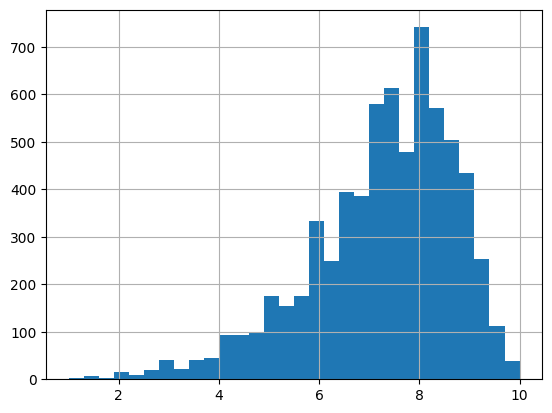

In [18]:
# Histograma critic score
df['critic_score'].hist(bins=30)

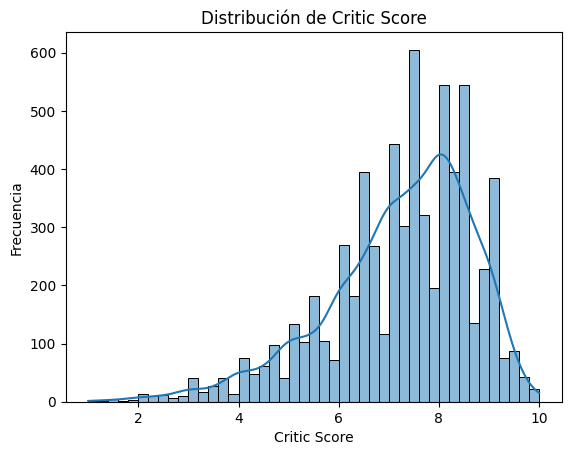

In [19]:
# Distribución del critic_score
sns.histplot(df[df['critic_score']!=-1]['critic_score'], kde=True)
plt.title('Distribución de Critic Score')
plt.xlabel('Critic Score')
plt.ylabel('Frecuencia')
plt.show()

<Axes: >

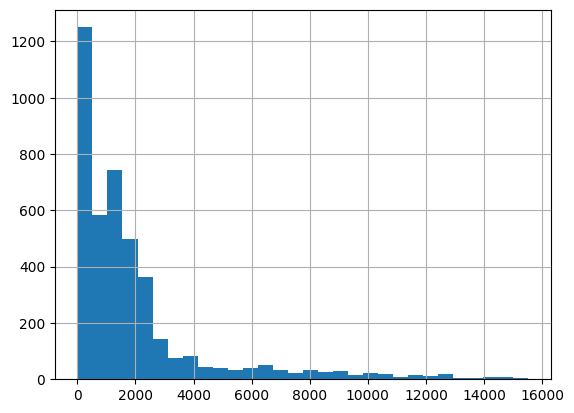

In [20]:
# Histograma edad videojuegos
df['age_days'].hist(bins=30)

<Axes: ylabel='total_sales'>

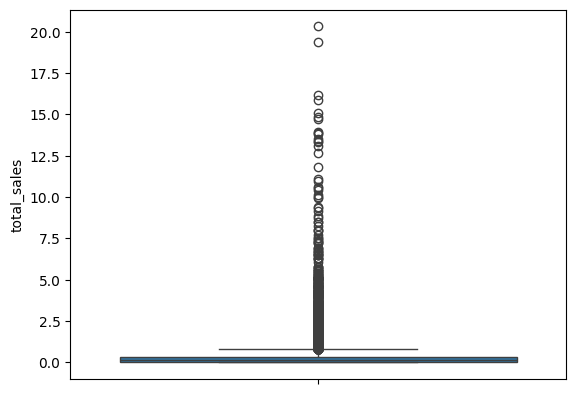

In [21]:
# Boxplot de total sales
sns.boxplot(y=df['total_sales'])

<Axes: ylabel='log_total_sales'>

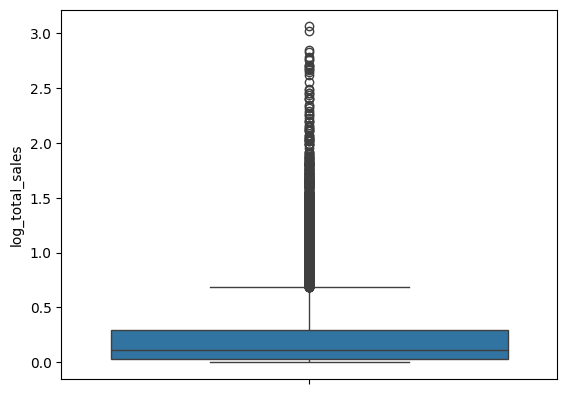

In [22]:
# Con logaritmo, para mejor visualización
df['log_total_sales'] = np.log1p(df['total_sales']) #Aprovechamos y creamos la columna, por si la necesitamos más adelante.

sns.boxplot(y=df['log_total_sales'])

In [23]:
# Función gráfico top n
# Plot simple de categorías
# Reutilizable, con tercer parámetro opcional(10 por defecto)

def plot_top_n(column, title, n=10):

    data = df

    if column == 'publisher':
        data = data[data['publisher'].astype(str).str.lower() != 'unknown'] #Quitamos los valores de "Unknown" en caso de que la columna sea 'publisher'

    top_n = data[column].value_counts().head(n)

    plt.figure(figsize=(8, 4))
    plt.bar(top_n.index, top_n.values)
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.xlabel(column.capitalize())
    plt.ylabel('Número de juegos')
    plt.tight_layout()
    plt.show()


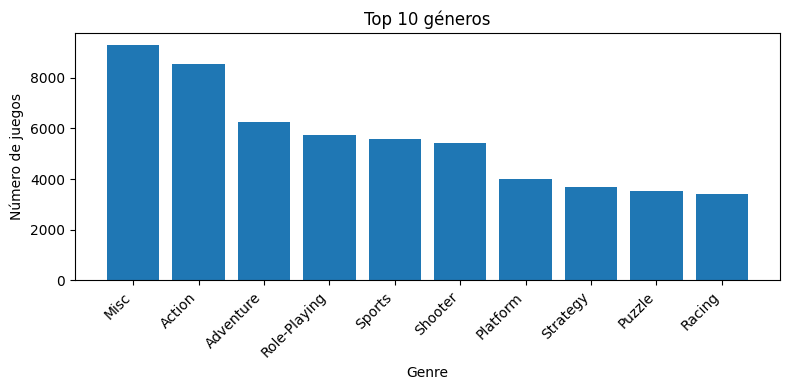

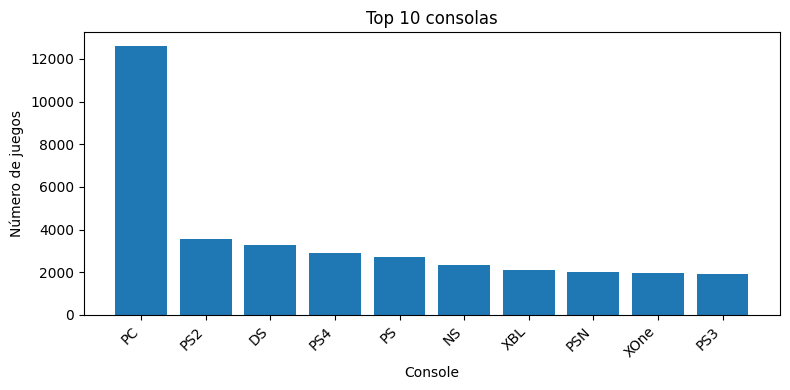

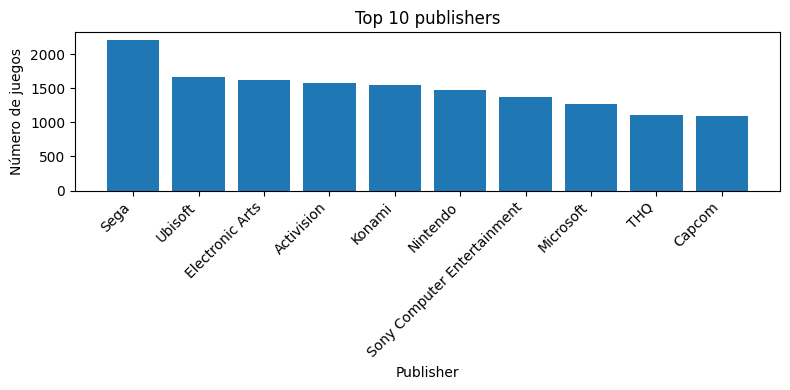

In [24]:
plot_top_n('genre', 'Top 10 géneros')
plot_top_n('console', 'Top 10 consolas')
plot_top_n('publisher', 'Top 10 publishers') #(Sin "Unknown")

In [25]:
# Si quiero ver cómo evolucionan en el tiempo
def plot_top_n_timeseries(category_col, time_col, value_col, n=5):

    # Por tiempo, y categoría
    g = (df.dropna(subset=[time_col, value_col])
           .groupby([category_col, time_col])[value_col]
           .sum()
           .reset_index())

    # Top-N categorías por total acumulado
    topN = (g.groupby(category_col)[value_col]
              .sum()
              .sort_values(ascending=False)
              .head(n)
              .index)

    plt.figure(figsize=(9, 5))
    for cat in topN:
        sub = g[g[category_col] == cat].sort_values(time_col)
        plt.plot(sub[time_col], sub[value_col], label=str(cat))

    plt.title(f"Evolución de {value_col} por {category_col} — Top {n}")
    plt.xlabel(time_col)
    plt.ylabel(value_col)
    plt.legend()
    plt.tight_layout()
    plt.show()


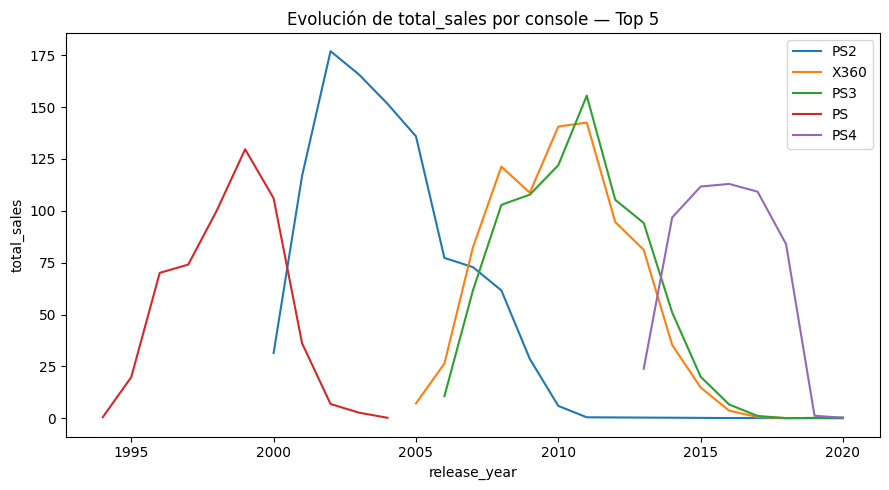

In [26]:
# Ya lo hemos convertido antes a fecha (datetime)

df['release_year'] = df['release_date'].dt.year.astype('Int64') # Año como entero
# Utilizamos el año en vez de la fecha, si no, la gráfica va saltando de fecha en fecha

plot_top_n_timeseries(
    category_col='console',
    time_col='release_year',
    value_col='total_sales',
    n=5
)

In [27]:
# Para ver el crecimiento de las consolas en comparación(desde su año de salida)
def plot_top_n_timeseries_aligned(category_col, time_col, value_col, n=5, cumulative=False):
    # Agrupar por categoría y año
    g = (df.dropna(subset=[category_col, time_col, value_col])
           .groupby([category_col, time_col])[value_col]
           .sum()
           .reset_index())

    # Top N categorías por total acumulado
    topN = (g.groupby(category_col)[value_col]
              .sum()
              .sort_values(ascending=False)
              .head(n)
              .index)

    # Año de lanzamiento por categoría
    launch_year = (g.groupby(category_col)[time_col]
                     .min()
                     .rename('launch_year'))
    g = g.merge(launch_year, on=category_col, how='left')

    # Años desde lanzamiento
    g['years_since_launch'] = g[time_col] - g['launch_year']

    plt.figure(figsize=(9, 5))
    for cat in topN:
        sub = g[g[category_col] == cat].sort_values('years_since_launch').copy()

        # Ventas acumuladas para ver la curva de crecimiento
        y = sub[value_col].cumsum() if cumulative else sub[value_col]

        plt.plot(sub['years_since_launch'], y, label=str(cat))

    ttl = f"Evolución de {value_col}{' (acumulado)' if cumulative else ''} alineada — Top {n}"
    plt.title(ttl)
    plt.xlabel("Años desde lanzamiento")
    plt.ylabel(value_col)
    plt.legend()
    plt.tight_layout()

    plt.show()


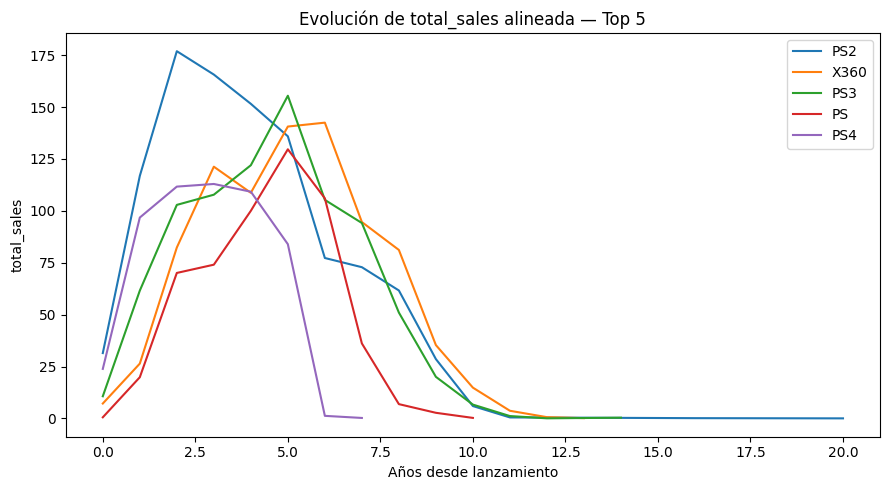

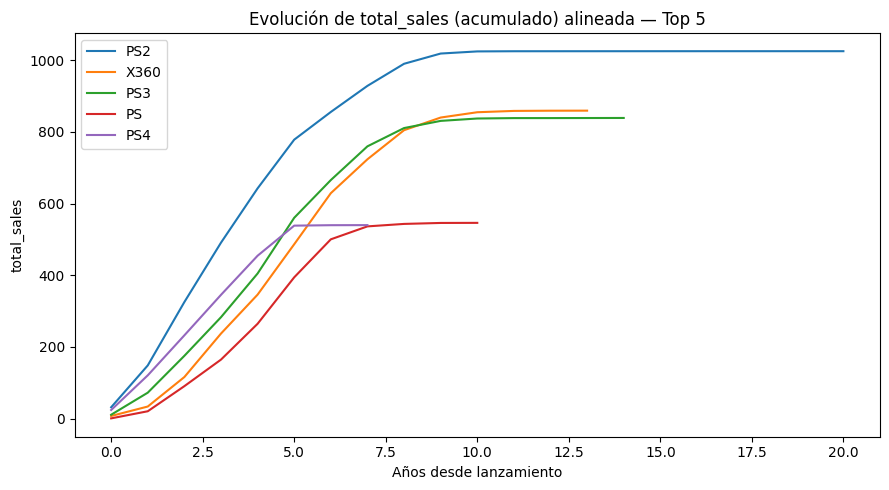

In [28]:
plot_top_n_timeseries_aligned(
    category_col='console',
    time_col='release_year',
    value_col='total_sales',
    n=5
)

# Para ver mejor el crecimiento de las ventas en comparación con el resto, utilizamos una curva acumulada
plot_top_n_timeseries_aligned(
    category_col='console',
    time_col='release_year',
    value_col='total_sales',
    n=5,
    cumulative=True
)


In [29]:
import plotly.express as px

# Sumar ventas por región
region_sales = {
    "North America": df["na_sales"].sum(),
    "Europe": df["pal_sales"].sum(),
    "Japan": df["jp_sales"].sum(),
    "Other": df["other_sales"].sum()
}

# Convertir a DataFrame
region_df = pd.DataFrame(list(region_sales.items()), columns=["Region", "Sales"])

# Mapeo a países reales
region_to_country = {
    "North America": "United States",
    "Europe": "France",
    "Japan": "Japan",
    "Other": "Australia"
}
region_df["Country"] = region_df["Region"].map(region_to_country)

region_df["Sales_M"] = region_df["Sales"]

# Crear el mapa con mejoras
fig = px.choropleth(
    region_df,
    locations="Country",
    locationmode="country names",
    color="Sales_M",
    hover_name="Region",
    color_continuous_scale="YlOrRd",
    title="Ventas Totales por Región (en millones)",
    projection="natural earth"
)

# Formato del hover y título más grande
fig.update_traces(
    hovertemplate='%{hovertext}<br>Ventas: %{z:.2f}M<extra></extra>'
)
fig.update_layout(
    width=700,
    height=500,
    title_font=dict(size=20),
    coloraxis_colorbar=dict(title="Millones")
)

fig.show()


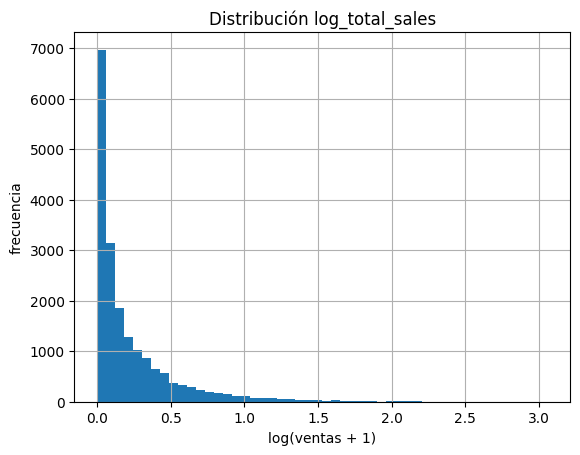

In [30]:
# Distribución de total_sales(utilizamos el log creado anteriormente, para una mejor visualización)
df['log_total_sales'].hist(bins=50)
plt.title('Distribución log_total_sales')
plt.xlabel('log(ventas + 1)')
plt.ylabel('frecuencia')
plt.show()

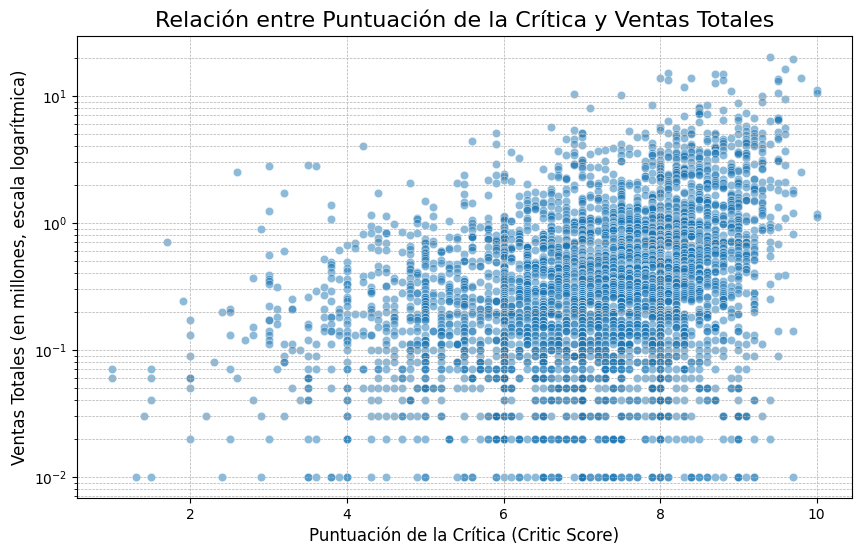

In [31]:
# Scatterplot critica y ventas

plt.figure(figsize=(10, 6))

# Usamos 'alpha=0.5' para que los puntos se vean mejor
sns.scatterplot(data=df, x='critic_score', y='total_sales', alpha=0.5)

# Utilizamos la escala logarítmica para manejar la asimetría de las ventas
plt.yscale('log')

plt.title('Relación entre Puntuación de la Crítica y Ventas Totales', fontsize=16)
plt.xlabel('Puntuación de la Crítica (Critic Score)', fontsize=12)
plt.ylabel('Ventas Totales (en millones, escala logarítmica)', fontsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.show()

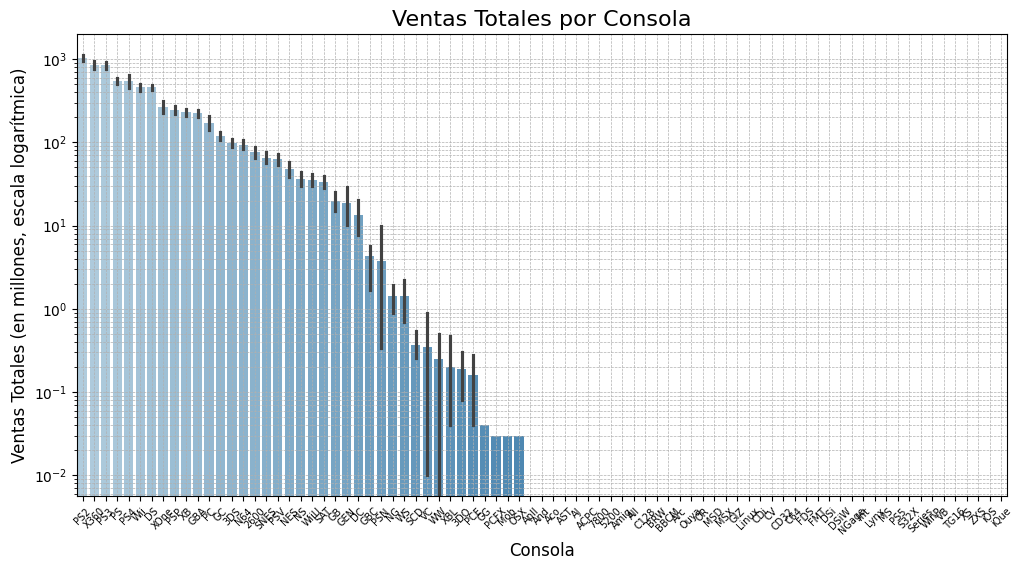

In [32]:
# Gráfico de barras con suma de ventas por consola

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='console',
    y='total_sales',
    estimator=sum,
    order=df.groupby('console')['total_sales'].sum().sort_values(ascending=False).index,
    palette="Blues_d"
)

plt.yscale('log')  # escala logarítmica para ver bien la diferencia
plt.title('Ventas Totales por Consola', fontsize=16)
plt.xlabel('Consola', fontsize=12)
plt.ylabel('Ventas Totales (en millones, escala logarítmica)', fontsize=12)
plt.xticks(rotation=45, fontsize=7)
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.show()


## Estudio de posibles correlaciones de variables

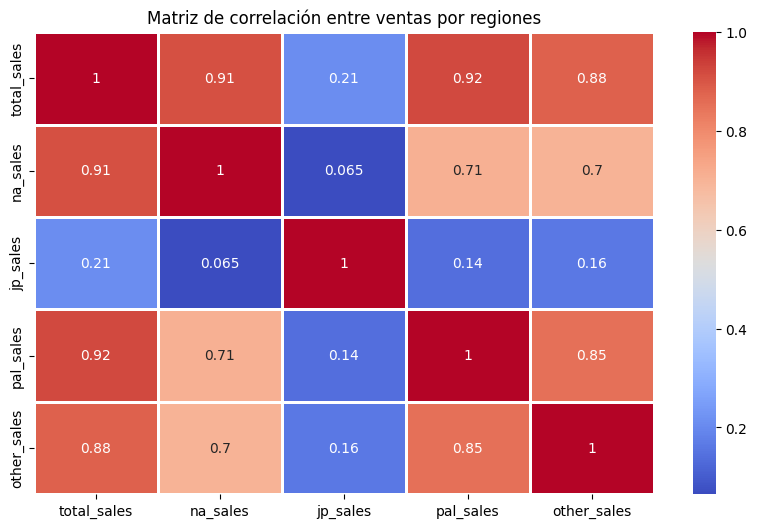

In [33]:
# Análisis de correlación (Ventas)
# Antes de calcular correlaciones, filtramos filas con datos completos en ventas.
cols_ventas = ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']

df_sales = df[cols_ventas].dropna()

# Matriz de correlaciones
corr_matrix = df_sales.corr()

# Visualización con mapa de calor

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=1)
plt.title('Matriz de correlación entre ventas por regiones')
plt.show()

# Modelos de predicción

Porcentaje de éxito sobre registros con datos de ventas: 7.95%


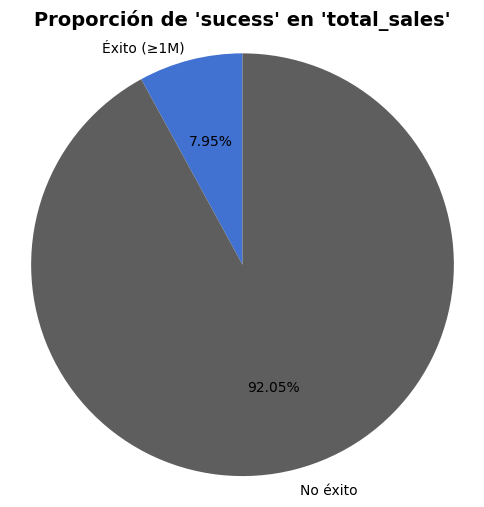

In [34]:
# Cálculo de porcentaje de éxito, para hacernos una idea previa(futura variable success).

# Filtramos registros válidos
valid_sales = df.dropna(subset=['total_sales'])

# Calcular clases
success_count = (valid_sales['total_sales'] >= 1.0).sum()
fail_count = (valid_sales['total_sales'] < 1.0).sum()

# Calcular porcentaje sobre válidos
porcentaje_sobre_validos = success_count / len(valid_sales) * 100
print(f"Porcentaje de éxito sobre registros con datos de ventas: {porcentaje_sobre_validos:.2f}%")

# Gráfico
plt.figure(figsize=(6,6))
plt.pie(
    [success_count, fail_count],
    labels=["\nÉxito (≥1M)", "No éxito"],
    autopct='%1.2f%%',
    colors=["#4171d1", "#5e5e5e"], # Azul / Gris
    startangle=90
)
plt.title("Proporción de 'sucess' en 'total_sales'", fontsize=14, fontweight="bold")
plt.axis('equal')
plt.show()



In [35]:
# Imports y semilla para replicación.
SEED = 1234
np.random.seed(SEED)

# Imports preprocesado
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_predict  # ROC/Curvas
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
                             cohen_kappa_score, confusion_matrix, classification_report,
                             precision_recall_curve, # PR
                             make_scorer)

# Imports modelos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

In [36]:
# Datos y preprocesado común

# XGBoost
try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False


# Datos base
if 'df_base' not in globals(): df_base = df.dropna(subset=["total_sales"]).copy()
if 'num_features' not in globals(): num_features = ["critic_score"]
if 'cat_features' not in globals(): cat_features = ["console","genre","release_year","publisher_simple"]
num_features = [c for c in num_features if c in df_base.columns]
cat_features = [c for c in cat_features if c in df_base.columns]
for c in num_features: df_base[c] = pd.to_numeric(df_base[c], errors="coerce")
for c in cat_features: df_base[c] = df_base[c].astype("object")
df_base[num_features+cat_features] = df_base[num_features+cat_features].replace({pd.NA: np.nan})

# Preprocesado
if 'preprocess' not in globals():
    preprocess = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler",  StandardScaler())]), num_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features)
    ])


In [37]:
# Etiqueta binaria, partición y peso de clase para desbalance

df_clf = df_base.copy()
df_clf["success"] = (df_clf["total_sales"] >= 1.0).astype(int)   # condición: mayor de 1 millón

X, y = df_clf[num_features + cat_features].copy(), df_clf["success"]
if all(v in globals() for v in ["X_train_c","X_test_c","y_train_c","y_test_c"]):
    X_train, X_test, y_train, y_test = X_train_c, X_test_c, y_train_c, y_test_c
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)

# Ratio negativos/positivos(en train)
neg, pos = (y_train==0).sum(), (y_train==1).sum()
SCALE_POS_WEIGHT = float(neg)/max(1.0, float(pos))
print(f"Prevalencia train: {y_train.mean():.3f} | test: {y_test.mean():.3f} | scale_pos_weight≈{SCALE_POS_WEIGHT:.2f}")


Prevalencia train: 0.080 | test: 0.080 | scale_pos_weight≈11.57


In [38]:
# Métricas, CV y funciones de evaluación

scoring = {"accuracy":"accuracy","balanced_accuracy":"balanced_accuracy","f1":"f1",
           "roc_auc":"roc_auc","kappa":make_scorer(cohen_kappa_score)}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluar(model, Xt, yt, nombre):
    """Evalúa con umbral por defecto (0.5)."""
    y_pred = model.predict(Xt)
    auc = (roc_auc_score(yt, model.predict_proba(Xt)[:,1]) if hasattr(model,"predict_proba")
           else roc_auc_score(yt, model.decision_function(Xt)) if hasattr(model,"decision_function") else np.nan)
    out = {"Modelo":nombre,
           "Accuracy":accuracy_score(yt,y_pred),
           "BalancedAcc":balanced_accuracy_score(yt,y_pred),
           "F1":f1_score(yt,y_pred),
           "Kappa":cohen_kappa_score(yt,y_pred),
           "ROC_AUC":auc}
    print(f"\n[{nombre}]"); print(pd.Series(out).round(4))
    print("Matriz de confusión:\n", confusion_matrix(yt, y_pred))
    print("\nClasification report:\n", classification_report(yt, y_pred, digits=3))
    return out

def evaluar_con_umbral(model, Xt, yt, thr, nombre):
    """Evalúa fijando un umbral custom (probabilidad/score ≥ thr → clase 1)."""
    s = model.predict_proba(Xt)[:,1] if hasattr(model,"predict_proba") else model.decision_function(Xt)
    y_pred = (s >= thr).astype(int)
    out = {"Modelo":nombre,
           "Accuracy":accuracy_score(yt,y_pred),
           "BalancedAcc":balanced_accuracy_score(yt,y_pred),
           "F1":f1_score(yt,y_pred),
           "Kappa":cohen_kappa_score(yt,y_pred),
           "ROC_AUC":roc_auc_score(yt,s)}
    print(f"\n[{nombre}]  thr={thr:.3f}"); print(pd.Series(out).round(4))
    print("Matriz de confusión:\n", confusion_matrix(yt, y_pred))
    print("\nClasification report:\n", classification_report(yt, y_pred, digits=3))
    return out


In [39]:
# Modelos base, comparación por CV y entrenamiento final único

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "Linear SVM (Calibrated)": CalibratedClassifierCV(
        estimator=LinearSVC(class_weight="balanced", random_state=SEED),
        method="sigmoid", cv=3
    ),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, min_samples_leaf=2,
                                            class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                            random_state=SEED, n_jobs=-1),
    ("XGBoost" if XGB_OK else "HistGBClassifier"):
        (XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=6,
                       subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, reg_alpha=0.0,
                       scale_pos_weight=SCALE_POS_WEIGHT,  # ajuste por desbalance
                       random_state=SEED, n_jobs=-1, eval_metric="logloss",
                       objective="binary:logistic", tree_method="hist")
         if XGB_OK else
         HistGradientBoostingClassifier(max_depth=None, learning_rate=0.1,
                                        max_iter=400, random_state=SEED))
}

resultados, pipelines_entrenados = [], {}
for nombre, clf in modelos.items():
    pipe  = Pipeline([("prep", preprocess), ("clf", clf)])
    cvres = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    resultados.append({
        "Modelo":             nombre,
        "Accuracy":           cvres["test_accuracy"].mean(),
        "Balanced Accuracy":  cvres["test_balanced_accuracy"].mean(),
        "F1":                 cvres["test_f1"].mean(),
        "Kappa":              cvres["test_kappa"].mean(),
        "ROC AUC":            cvres["test_roc_auc"].mean()
    })
    pipe.fit(X_train, y_train)  # fit final del base (train completo)
    pipelines_entrenados[nombre] = pipe

tabla_cv = pd.DataFrame(resultados).sort_values(
    by=["F1", "Balanced Accuracy", "ROC AUC"], ascending=False
)
display(tabla_cv.round(4))

mejor_nombre = tabla_cv.iloc[0]["Modelo"]
print("\nMejor por CV (F1/BalAcc):", mejor_nombre)
mejor_base = pipelines_entrenados[mejor_nombre]


,Modelo,Accuracy,Balanced Accuracy,F1,Kappa,ROC AUC
4,XGBoost,0.8440,0.7449,0.3897,0.3147,0.8413
0,Logistic Regression,0.7385,0.7457,0.3146,0.2159,0.8166
2,Decision Tree,0.8259,0.6732,0.3099,0.2256,0.6883
3,Random Forest,0.8880,0.6106,0.2851,0.2245,0.7968
1,Linear SVM (Calibrated),0.9240,0.5353,0.1326,0.1197,0.8149



Mejor por CV (F1/BalAcc): XGBoost


In [40]:
# Tuning corto del modelo con mejores resultados
# (En este caso, ha sido el XGBoost)

param_spaces = {}
if   mejor_nombre == "Random Forest":
    param_spaces = {"clf__n_estimators":[300,500,800],"clf__max_depth":[None,8,16],
                    "clf__min_samples_leaf":[1,2,5],"clf__max_features":["sqrt",0.5,0.8]}
elif mejor_nombre == "Decision Tree":
    param_spaces = {"clf__max_depth":[None,6,10,16],"clf__min_samples_leaf":[1,2,5,10],
                    "clf__criterion":["gini","entropy","log_loss"]}
elif mejor_nombre == "Logistic Regression":
    param_spaces = {"clf__C":[0.1,0.5,1.0,2.0,5.0],"clf__penalty":["l2"],"clf__solver":["lbfgs","liblinear"]}
elif mejor_nombre == "Linear SVM (Calibrated)":
    param_spaces = {"clf__base_estimator__C":[0.1,0.5,1.0,2.0,5.0]}
elif mejor_nombre == "XGBoost":
    param_spaces = {"clf__n_estimators":[300,600,900],
                    "clf__learning_rate":[0.05,0.1,0.2],
                    "clf__max_depth":[3,6,8],
                    "clf__subsample":[0.8,1.0],
                    "clf__colsample_bytree":[0.7,0.9,1.0],
                    "clf__reg_lambda":[0.5,1.0,2.0],
                    "clf__scale_pos_weight":[SCALE_POS_WEIGHT*0.5, SCALE_POS_WEIGHT, SCALE_POS_WEIGHT*1.5]}

best_model = mejor_base
if param_spaces:
    tuner = RandomizedSearchCV(mejor_base, param_spaces, n_iter=16, scoring="f1", cv=cv, n_jobs=-1,
                               random_state=SEED, verbose=0)
    tuner.fit(X_train, y_train)
    best_model = tuner.best_estimator_
    print("\nMejores hiperparámetros:", tuner.best_params_)



Mejores hiperparámetros: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 5.786129568106312, 'clf__reg_lambda': 2.0, 'clf__n_estimators': 900, 'clf__max_depth': 6, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.9}


In [41]:
# Umbral óptimo (max F1) y evaluación final (en test)

meth = "predict_proba" if hasattr(best_model, "predict_proba") else "decision_function"
scores_oof = cross_val_predict(best_model, X_train, y_train, cv=cv, method=meth)
if meth == "predict_proba": scores_oof = scores_oof[:,1]
p, r, thr = precision_recall_curve(y_train, scores_oof)
f1s = 2*p*r/(p+r+1e-12)
thr_star = float(thr[np.argmax(f1s[:-1])])   # umbral que maximiza F1 en OOF

res_base  = evaluar(mejor_base, X_test, y_test, f"{mejor_nombre} (Base)")
res_tuned = evaluar(best_model,  X_test, y_test, f"{mejor_nombre} (Tuned)")
res_thr   = evaluar_con_umbral(best_model, X_test, y_test, thr_star, f"{mejor_nombre} (Tuned+thr)")

tabla_final = (pd.DataFrame([res_base, res_tuned, res_thr])
               [["Modelo","Accuracy","BalancedAcc","F1","Kappa","ROC_AUC"]]
               .sort_values(by=["F1","BalancedAcc","ROC_AUC"], ascending=False))
display(tabla_final.round(4))



[XGBoost (Base)]
Modelo         XGBoost (Base)
Accuracy             0.845971
BalancedAcc          0.773676
F1                   0.415246
Kappa                0.342211
ROC_AUC              0.861818
dtype: object
Matriz de confusión:
 [[2995  489]
 [  94  207]]

Clasification report:
               precision    recall  f1-score   support

           0      0.970     0.860     0.911      3484
           1      0.297     0.688     0.415       301

    accuracy                          0.846      3785
   macro avg      0.633     0.774     0.663      3785
weighted avg      0.916     0.846     0.872      3785


[XGBoost (Tuned)]
Modelo         XGBoost (Tuned)
Accuracy              0.891149
BalancedAcc           0.752688
F1                    0.462141
Kappa                 0.404661
ROC_AUC               0.868303
dtype: object
Matriz de confusión:
 [[3196  288]
 [ 124  177]]

Clasification report:
               precision    recall  f1-score   support

           0      0.963     0.917     0.9

,Modelo,Accuracy,BalancedAcc,F1,Kappa,ROC_AUC
2,XGBoost (Tuned+thr),0.9173,0.7290,0.4927,0.4477,0.8683
1,XGBoost (Tuned),0.8911,0.7527,0.4621,0.4047,0.8683
0,XGBoost (Base),0.8460,0.7737,0.4152,0.3422,0.8618


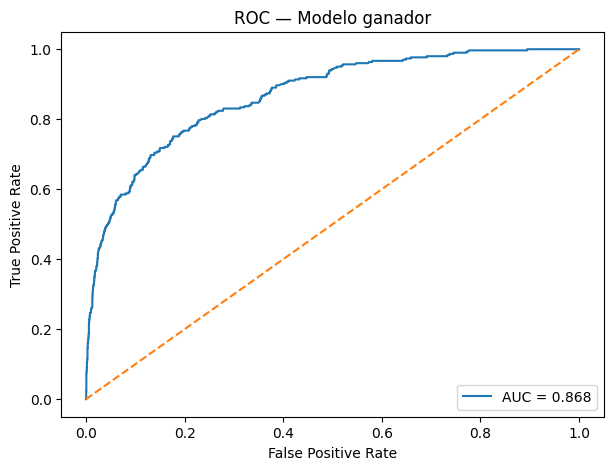

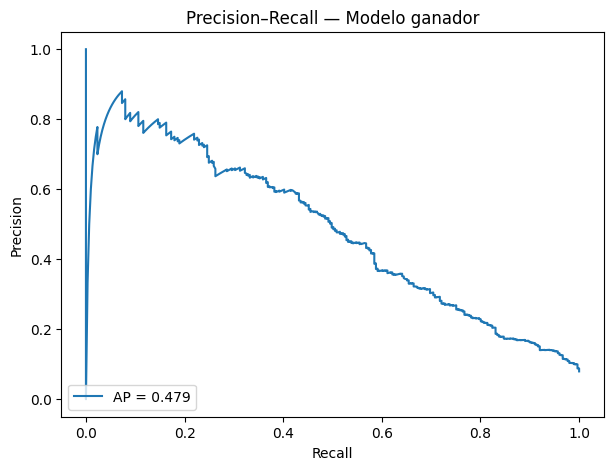

In [42]:
# Curvas ROC y Precision–Recall(del ganador)
# (usa best_model ya entrenado y el umbral thr_star calculado)

from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Scores del ganador en TEST
if hasattr(best_model, "predict_proba"):
    scores_test = best_model.predict_proba(X_test)[:, 1]
else:
    scores_test = best_model.decision_function(X_test)

# ROC
fpr, tpr, roc_thr = roc_curve(y_test, scores_test)
auc = roc_auc_score(y_test, scores_test)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC — Modelo ganador")
plt.legend(loc="lower right")
plt.show()

# Precision–Recall
prec, rec, pr_thr = precision_recall_curve(y_test, scores_test)
ap = average_precision_score(y_test, scores_test)

plt.figure(figsize=(7,5))
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall — Modelo ganador")
plt.legend(loc="lower left")
plt.show()

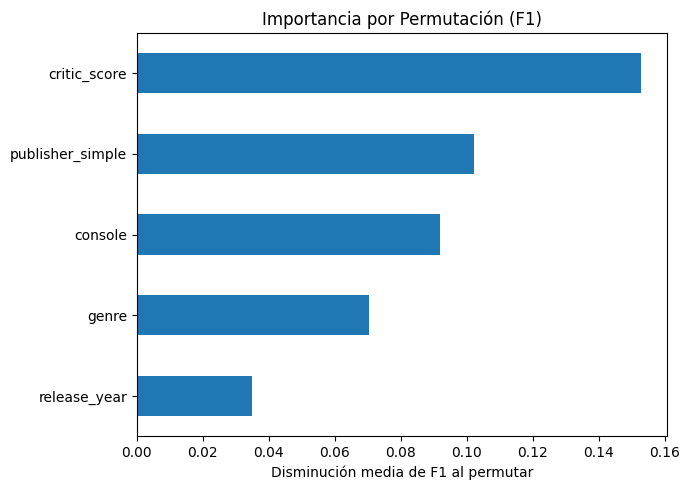

,feature,importance_mean
0,critic_score,0.152944
1,publisher_simple,0.102218
2,console,0.091869
3,genre,0.070518
4,release_year,0.034851


In [43]:
# Importancia de variables (Permutation Importance)

from sklearn.inspection import permutation_importance

rng = np.random.RandomState(SEED)
n_pi = min(1000, len(X_test))
idx = rng.choice(len(X_test), size=n_pi, replace=False)
X_pi, y_pi = X_test.iloc[idx], y_test.iloc[idx]

pi = permutation_importance(best_model, X_pi, y_pi, n_repeats=5, random_state=SEED, scoring="f1", n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False)

top = imp.head(10)
ax = top.sort_values().plot(kind="barh", figsize=(7,5))
ax.set_title("Importancia por Permutación (F1)")
ax.set_xlabel("Disminución media de F1 al permutar")
plt.tight_layout(); plt.show()

top_df = top.reset_index()
top_df.columns = ["feature","importance_mean"]
display(top_df)

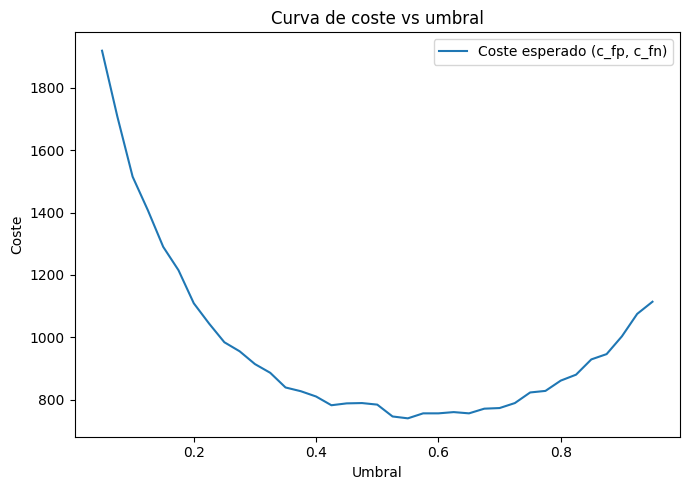

Umbral de menor coste (c_fp=1.0, c_fn=4.0): thr* = 0.550  |  coste = 740


,thr,F1,BalancedAcc,Precision,Recall
0,0.613783,0.492707,0.728956,0.481013,0.504983
1,0.550000,0.494220,0.752480,0.437340,0.568106


In [44]:
# Umbral vs coste: curva y umbral mínimo coste

from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score

# Costes relativos: FP (falso positivo) y FN (falso negativo)
c_fp, c_fn = 1.0, 4.0
thr_grid = np.linspace(0.05, 0.95, 37)

def counts_for_threshold(scores, y_true, thr):
    y_pred = (scores >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn, fp, fn, tp

costs, f1s = [], []
for thr in thr_grid:
    tn, fp, fn, tp = counts_for_threshold(scores_test, y_test, thr)
    costs.append(c_fp*fp + c_fn*fn)
    f1s.append((2*tp) / max(1, 2*tp + fp + fn))

thr_min = float(thr_grid[int(np.argmin(costs))])
cost_min = float(np.min(costs))

plt.figure(figsize=(7,5))
plt.plot(thr_grid, costs, label="Coste esperado (c_fp, c_fn)")
plt.xlabel("Umbral"); plt.ylabel("Coste")
plt.title("Curva de coste vs umbral")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Umbral de menor coste (c_fp={c_fp}, c_fn={c_fn}): thr* = {thr_min:.3f}  |  coste = {cost_min:.0f}")

def quick_metrics_at(thr):
    y_pred = (scores_test >= thr).astype(int)
    return {
        "thr": thr,
        "F1": f1_score(y_test, y_pred),
        "BalancedAcc": balanced_accuracy_score(y_test, y_pred),
        "Precision": ((y_pred & (y_test==1)).sum() / max(1, (y_pred==1).sum())),
        "Recall": ((y_pred & (y_test==1)).sum() / max(1, (y_test==1).sum()))
    }

comp = pd.DataFrame([quick_metrics_at(thr_star), quick_metrics_at(thr_min)])
display(comp)


In [45]:
# Validación temporal(por release_year)
# (entrena en años tempranos y evalúa en años recientes)

years = pd.to_numeric(df_clf["release_year"], errors="coerce")
mask_valid = years.notna()
Xy = df_clf.loc[mask_valid, :]
years = years.loc[mask_valid]

# Entrenamos hasta el percentil 80 de años y test en el tramo más reciente
y_cut = np.nanpercentile(years, 80)
tr_mask = years <= y_cut
te_mask = years >  y_cut

X_tr, X_te = Xy.loc[tr_mask, num_features+cat_features], Xy.loc[te_mask, num_features+cat_features]
y_tr, y_te = Xy.loc[tr_mask, "success"],              Xy.loc[te_mask, "success"]

# Re-entrenar el ganador(con la misma configuración) y evaluar
ganador = best_model
ganador.fit(X_tr, y_tr)

print(f"Split temporal: train ≤ {int(y_cut)} ({tr_mask.sum()} filas), test > {int(y_cut)} ({te_mask.sum()} filas)")
_ = evaluar(ganador, X_te, y_te, f"{mejor_nombre} (Temporal holdout)")



Split temporal: train ≤ 2013 (15538 filas), test > 2013 (3294 filas)

[XGBoost (Temporal holdout)]
Modelo         XGBoost (Temporal holdout)
Accuracy                         0.806011
BalancedAcc                      0.768797
F1                               0.339193
Kappa                            0.261545
ROC_AUC                          0.856966
dtype: object
Matriz de confusión:
 [[2491  577]
 [  62  164]]

Clasification report:
               precision    recall  f1-score   support

           0      0.976     0.812     0.886      3068
           1      0.221     0.726     0.339       226

    accuracy                          0.806      3294
   macro avg      0.599     0.769     0.613      3294
weighted avg      0.924     0.806     0.849      3294

